In [1]:
# Hidden setup cell (imports, deterministic seed, global dt).
%matplotlib inline
import brainmass
import brainstate
import braintools
import brainunit as u
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Resting-State MEG: A Whole-Brain Modeling Pipeline

This case study walks through the classic **resting-state** workflow: take a structural
connectome, simulate a whole-brain neural-mass network on it, project the regional activity
through a forward model to a sensor-space MEG signal, and finally validate the model by
comparing its **functional connectivity** (FC) against an empirical target.

```
structural connectome  →  whole-brain Network  →  forward model  →  functional connectivity
       (anatomy)             (dynamics)            (MEG sensors)        (validation target)
```

In a real study the connectome and the empirical MEG would come from imaging data (e.g. an HCP
diffusion-MRI tractography matrix and a parcellated MEG recording). To keep this notebook
**fully self-contained and executable with no downloads**, we drive the entire pipeline with
the bundled {func}`brainmass.datasets.load_dataset` connectome and a *synthetic* empirical
target. The prose flags exactly where your own data would plug in.

**Source:** modernized from the resting-state MEG example shipped with brainmass; the
hand-rolled simulation loop is replaced by the high-level {class}`~brainmass.Network` /
{class}`~brainmass.Simulator` API.

## 1. The structural connectome

{func}`brainmass.datasets.load_dataset('example_connectome') <brainmass.datasets.load_dataset>`
returns an 8-region {class}`~brainmass.datasets.Connectome`: a symmetric, zero-diagonal weight
matrix in `[0, 1]`, a unit-aware (`mm`) inter-region distance matrix, and region labels. The
distances set the **conduction delays** (`delay = distance / speed`).

:::{note}
**Plugging in real data.** Replace this block with your own subject connectome: an `(N, N)`
weight matrix from tractography and an `(N, N)` Euclidean (or fiber-length) distance matrix in
`mm`. Everything downstream is `N`-agnostic.
:::

8 regions: [np.str_('R0'), np.str_('R1'), np.str_('R2'), np.str_('R3'), np.str_('R4'), np.str_('R5'), np.str_('R6'), np.str_('R7')]
weights  : (8, 8) range [0.00, 1.00]
distances: (8, 8) unit mm


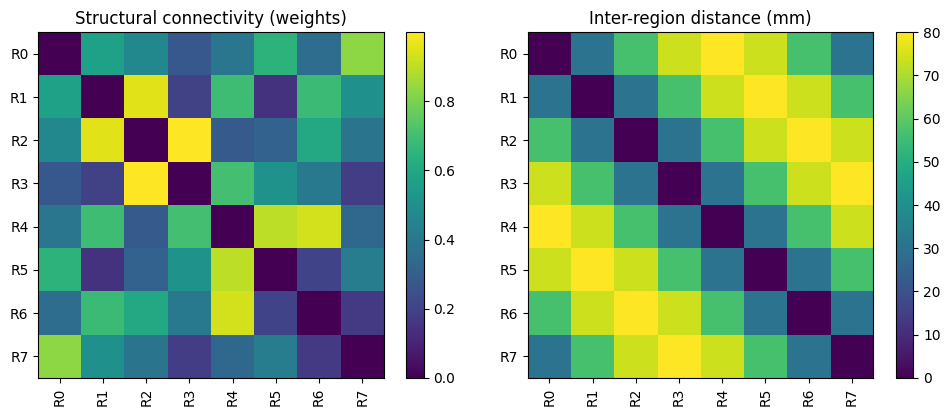

In [2]:
conn = brainmass.datasets.load_dataset('example_connectome')
W = conn.weights              # (8, 8) structural connectivity, [0, 1]
D = conn.distances            # (8, 8) distances, unit-aware (mm)
labels = list(conn.labels)    # ['R0', ..., 'R7']
N = W.shape[0]
print(f"{N} regions:", labels)
print("weights  :", W.shape, "range", f"[{W.min():.2f}, {W.max():.2f}]")
print("distances:", D.shape, "unit", D.unit)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
brainmass.viz.plot_connectivity(W, labels=labels, ax=axes[0])
axes[0].set_title('Structural connectivity (weights)')
brainmass.viz.plot_connectivity(u.get_magnitude(D), labels=labels, ax=axes[1])
axes[1].set_title('Inter-region distance (mm)')
plt.tight_layout()
plt.show()

## 2. The whole-brain network

We place a {class}`~brainmass.WilsonCowanStep` excitatory/inhibitory node at every region and
wire them with **diffusive** coupling on the excitatory rate `rE`, with conduction delays from
`distance / speed`. Per-region {class}`~brainmass.OUProcess` noise on `rE` keeps the resting
state from collapsing to a single fixed point (so the FC is non-degenerate). This single
{class}`~brainmass.Network` object replaces the connectome wiring that used to be copy-pasted by
hand across every example.

:::{note}
A delay-coupled `Network` sizes its delay buffers from the global `dt` **at construction time**,
so `brainstate.environ.set(dt=...)` is called once in the setup cell before we build it.
:::

In [3]:
node = brainmass.WilsonCowanStep(
    N,
    noise_E=brainmass.OUProcess(N, sigma=0.01, tau=20.0 * u.ms),
    noise_I=brainmass.OUProcess(N, sigma=0.01, tau=20.0 * u.ms),
)
net = brainmass.Network(
    node,
    conn=W,
    distance=D,
    speed=10.0 * u.mm / u.ms,    # axonal conduction speed
    coupling='diffusive',
    coupled_var='rE',
    k=1.5,                       # global coupling strength (TVB's G)
)
print("network:", net.n_node, "regions, coupling =", type(net.coupling).__name__)

network: 8 regions, coupling = DiffusiveCoupling


## 3. Simulate resting-state activity

{class}`~brainmass.Simulator` runs the whole network with one call. We discard an initial
transient and record the excitatory rate of every region.

activity: (37000, 8)


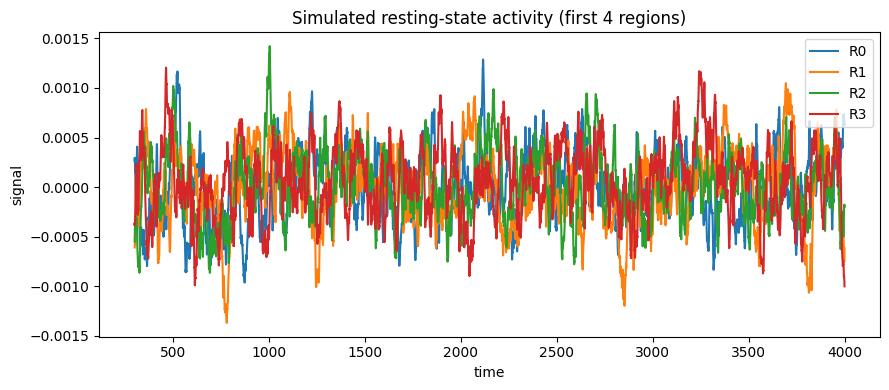

In [4]:
sim = brainmass.Simulator(net, dt=0.1 * u.ms)
res = sim.run(
    4000.0 * u.ms,
    monitors=lambda m: m.node.rE.value,   # (T, N) excitatory rates
    transient=300.0 * u.ms,
)
activity = res['output']                  # (T, N)
print("activity:", activity.shape)

fig, ax = plt.subplots(figsize=(9, 4))
brainmass.viz.plot_timeseries(activity[:, :4], ts=res['ts'], labels=labels[:4], ax=ax)
ax.set_title('Simulated resting-state activity (first 4 regions)')
plt.tight_layout()
plt.show()

## 4. Forward model: regions → MEG sensors

Neural activity is observed at the scalp, not in the cortex. A **lead field** `L` linearly maps
the `N` regional source amplitudes to `M` sensor measurements: `y = scale · source · L`. Here we
use {class}`~brainmass.MEGLeadFieldModel` with a synthetic geometric lead field (a real study
supplies a head-model lead field, e.g. from MNE/Brainstorm). We treat the excitatory rate as the
dipole source amplitude.

:::{note}
**Plugging in real data.** Replace `L` with your forward operator of shape `(N_regions,
N_sensors)` carrying units `sensor_unit / (nA·m)`. The lead field is the only geometry-specific
ingredient.
:::

sensor MEG: (37000, 16) unit T


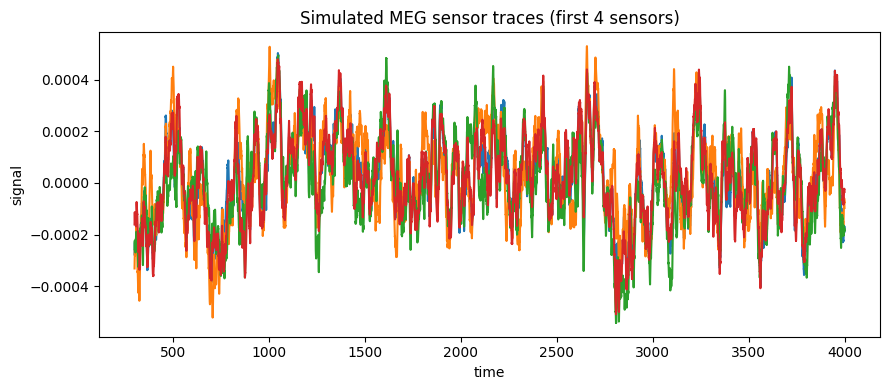

In [5]:
M = 16  # number of MEG sensors
# Synthetic geometric lead field: each region projects to sensors with a smooth,
# distance-like falloff. A real lead field comes from a head model.
rng = np.random.default_rng(1)
L_raw = np.abs(rng.standard_normal((N, M))) + 0.1
L_raw = L_raw / L_raw.sum(axis=0, keepdims=True)   # column-normalize
L = jnp.asarray(L_raw) * (u.tesla / (u.nA * u.meter))

# Base LeadFieldModel with an explicit mV-source -> dipole scale, so an mV source
# yields a correct tesla MEG output.
meg = brainmass.LeadFieldModel(
    in_size=(N,), out_size=(M,), L=L,
    sensor_unit=u.tesla,
    scale=u.nA * u.meter / u.mV,
)
# Treat the (dimensionless) excitatory rate as an mV-scale dipole source amplitude.
sources = jnp.asarray(u.get_magnitude(activity)) * u.mV   # (T, N)
sensor_meg = meg.update(sources)                          # (T, M), unit: tesla
print("sensor MEG:", sensor_meg.shape, "unit", u.get_unit(sensor_meg))

fig, ax = plt.subplots(figsize=(9, 4))
brainmass.viz.plot_timeseries(u.get_magnitude(sensor_meg)[:, :4], ts=res['ts'], ax=ax)
ax.set_title('Simulated MEG sensor traces (first 4 sensors)')
plt.tight_layout()
plt.show()

## 5. Validate the functional connectivity

The standard resting-state validation asks two questions of the simulated **functional
connectivity** (FC) — the region-by-region correlation of the activity:

1. **Does FC reflect the anatomy?** A good whole-brain model produces an FC that is shaped by the
   structural connectome. We measure this as the correlation between the off-diagonal FC and the
   structural weights — the canonical *structure-function* coupling.
2. **Does FC match a target recording?** We build a synthetic "empirical" target by running the
   same model with a different noise realization (standing in for real data with the same
   parcellation) and score the match with {func}`brainmass.objectives.fc_corr`.

:::{note}
**Plugging in real data.** Replace `target_activity` with your parcellated empirical recording of
shape `(T, N)`; the FC and both scores are computed identically. With short stochastic recordings,
FC correlations of a few tenths are realistic — structure-function coupling is the more robust
validation.
:::

In [6]:
# --- Synthetic "empirical" target (stands in for a real MEG recording) ---
brainstate.random.seed(123)
target_node = brainmass.WilsonCowanStep(
    N,
    noise_E=brainmass.OUProcess(N, sigma=0.01, tau=20.0 * u.ms),
    noise_I=brainmass.OUProcess(N, sigma=0.01, tau=20.0 * u.ms),
)
target_net = brainmass.Network(
    target_node, conn=W, distance=D, speed=10.0 * u.mm / u.ms,
    coupling='diffusive', coupled_var='rE', k=1.5,
)
target_res = brainmass.Simulator(target_net, dt=0.1 * u.ms).run(
    4000.0 * u.ms, monitors=lambda m: m.node.rE.value, transient=300.0 * u.ms)
target_activity = target_res['output']

# --- Functional connectivity: simulated vs target ---
fc_sim = braintools.metric.functional_connectivity(u.get_magnitude(activity))
fc_tar = braintools.metric.functional_connectivity(u.get_magnitude(target_activity))

# (1) Structure-function coupling: does the simulated FC reflect the connectome?
triu = np.triu_indices(N, k=1)
sc_fc_corr = float(np.corrcoef(fc_sim[triu], np.asarray(W)[triu])[0, 1])
# (2) Simulated vs target FC.
fc_match = float(brainmass.objectives.fc_corr()(activity, target_activity))
print(f"structure-function coupling  corr(FC, SC): {sc_fc_corr:.3f}")
print(f"FC correlation (simulated vs target)     : {fc_match:.3f}")

structure-function coupling  corr(FC, SC): 0.658
FC correlation (simulated vs target)     : 0.343


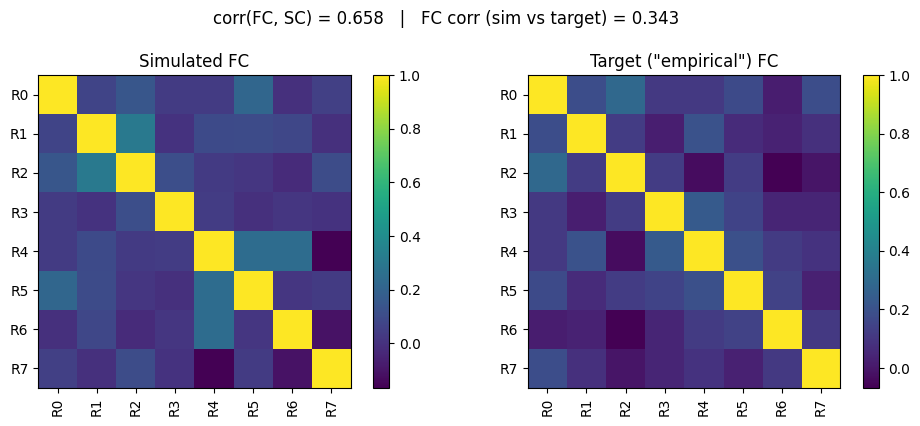

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
brainmass.viz.plot_functional_connectivity(fc_sim, is_matrix=True, labels=labels, ax=axes[0])
axes[0].set_title('Simulated FC')
brainmass.viz.plot_functional_connectivity(fc_tar, is_matrix=True, labels=labels, ax=axes[1])
axes[1].set_title('Target ("empirical") FC')
plt.suptitle(f'corr(FC, SC) = {sc_fc_corr:.3f}   |   FC corr (sim vs target) = {fc_match:.3f}',
             y=1.02)
plt.tight_layout()
plt.show()

## Summary

We ran the complete resting-state pipeline end to end:

1. loaded a **structural connectome** ({func}`~brainmass.datasets.load_dataset`),
2. built a delay-coupled whole-brain {class}`~brainmass.Network` of Wilson-Cowan nodes,
3. simulated it with {class}`~brainmass.Simulator`,
4. projected the activity to **MEG sensors** through a lead-field forward model, and
5. validated the model by **structure-function coupling** and **FC correlation**
   ({func}`~brainmass.objectives.fc_corr`).

To turn this into a real study, swap the three flagged blocks — connectome, lead field, and
target activity — for your imaging data; the modeling code is unchanged. The next natural step is
to *fit* the coupling strength `k` so the simulated FC best matches the target, which is exactly
what {class}`~brainmass.Fitter` does (see the EEG-fitting case study).